In [1]:
import experiment_utils
from experiment_utils import config

config.experiment_name = "inHomo_realHelmholtz_dirichlet_2d"
config.target = "jmlr_docker"
config.debug_mode = True

In [2]:
import numpy as np
import probnum as pn
import linpde_gp

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
import matplotlib.pyplot as plt
from matplotlib import patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

In [4]:
%matplotlib inline

In [5]:
plt.style.use('default')
plt.rcParams.update(config.tueplots_bundle())
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amsfonts}',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
})
plt.rcParams['text.usetex'] = True

In [6]:
cmap_mean = 'plasma'
cmap_uncertainty = 'viridis'
cmap_diverging = 'RdBu_r'

In [7]:
def plot_problem_setup(bvp, X_bc_list, X_pde):
    """
    Visualize the computational domain with boundary and PDE observation points.
    """
    fig = plt.figure(figsize=(7, 6))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1],
                           hspace=0.35, wspace=0.35, figure=fig)
    
    # Domain with observation points (2D view)
    ax1 = fig.add_subplot(gs[0, :])
    
    # Plot domain outline
    domain_box = patches.Rectangle(
        (-1, -1), 2, 2, linewidth=2, 
        edgecolor='black', facecolor='none', linestyle='-'
    )
    ax1.add_patch(domain_box)
    
    # Plot boundary condition points
    for i, X_bc in enumerate(X_bc_list):
        ax1.scatter(X_bc[:, 0], X_bc[:, 1], s=50, marker='o', 
                   c=f'C{i}', edgecolors='black', linewidth=0.5,
                   label=f'Boundary {i+1}', zorder=5, alpha=0.8)
    
    # Plot PDE observation points (interior)
    X_pde_flat = X_pde.reshape(-1, 2)
    ax1.scatter(X_pde_flat[:, 0], X_pde_flat[:, 1], s=30, marker='s',
               c='darkred', edgecolors='black', linewidth=0.5,
               label='PDE collocation', zorder=4, alpha=0.7)
    
    ax1.set_xlim(-1.2, 1.2)
    ax1.set_ylim(-1.2, 1.2)
    ax1.set_xlabel(r'$x_1$', fontsize=11)
    ax1.set_ylabel(r'$x_2$', fontsize=11)
    ax1.set_title('(a) Computational Domain and Observation Points', 
                  fontsize=12, fontweight='bold', loc='left')
    ax1.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='gray')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Number of observations
    ax2 = fig.add_subplot(gs[1, 0])
    
    n_boundary = sum(len(X_bc) for X_bc in X_bc_list)
    n_pde = len(X_pde_flat)
    
    categories = ['Boundary\nConditions', 'PDE\nCollocation', 'Total']
    counts = [n_boundary, n_pde, n_boundary + n_pde]
    colors = ['steelblue', 'darkred', 'gray']
    
    bars = ax2.bar(categories, counts, color=colors, alpha=0.7, 
                   edgecolor='black', linewidth=0.8)
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{int(count)}', ha='center', va='bottom', fontsize=9)
    
    ax2.set_ylabel('Number of Observations', fontsize=10)
    ax2.set_title('(b) Observation Counts', fontsize=12, 
                  fontweight='bold', loc='left')
    ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.set_ylim(0, max(counts) * 1.15)
    
    # Domain dimensions
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')
    
    info_text = (
        r'$\textbf{Problem Parameters:}$' + '\n\n'
        r'Domain: $\Omega = [-1, 1]^2$' + '\n'
        r'Equation: $\nabla^2 u + \kappa^2 u = f$' + '\n'
        rf'$\rho = {bvp.pde.rho:.1f}$, $\omega = {bvp.pde.omega:.1f}$' + '\n'
        rf'$G^\prime = {bvp.pde.G_complex.real:.1f}$, '
        rf'$G^{{\prime\prime}} = {bvp.pde.G_complex.imag:.1f}$' + '\n'
        rf'$\kappa^2 = {bvp.pde.k_squared:.2f}$' + '\n\n'
        r'$\textbf{Discretization:}$' + '\n'
        f'Boundary points: {n_boundary}\n'
        f'Interior points: {n_pde}\n'
        f'Total observations: {n_boundary + n_pde}'
    )
    
    ax3.text(0.05, 0.95, info_text, transform=ax3.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3,
                     edgecolor='gray', linewidth=0.8))
    
    return fig

def plot_posterior_solution(
    plt_grid, u_post, X_pde=None, X_bc_list=None,
    extent=(-1, 1, -1, 1), figsize=(5.5, 2.4),
    show_domain_outline=True,
):
    grid_coords = np.asarray(plt_grid)
    Ny, Nx = grid_coords.shape[:2]
    X_flat = grid_coords.reshape(-1, 2)
    
    # Build explicit conditioning constraints for annotation
    cond_explicit = []
    if X_bc_list is not None:
        cond_explicit.append(r'$u|_{\partial \Omega} = g$')
    if X_pde is not None:
        cond_explicit.append(r'$(\Delta + \kappa^2) u(\mathbf{x}_i) = f(\mathbf{x}_i)$')
    
    u_mean = np.asarray(u_post.mean(grid_coords))
    if u_mean.shape != (Ny, Nx):
        u_mean = u_mean.reshape(Ny, Nx)
    
    with np.errstate(invalid='ignore'):
        u_std = np.asarray(u_post.std(X_flat)).reshape(Ny, Nx)
    u_std = np.maximum(np.nan_to_num(u_std, nan=0.0), 0.0)
    
    # Use half-width
    u_ci = 1.96 * u_std
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    
    # (a) Posterior mean
    im1 = axes[0].imshow(
        u_mean, cmap='plasma', extent=extent, origin='lower',
        aspect='equal', interpolation='bilinear'
    )
    axes[0].set_xlabel(r'$x_1$')
    axes[0].set_ylabel(r'$x_2$')
    axes[0].set_title(r'\textbf{a}', loc='left', fontweight='bold')
    cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    cbar1.set_label(r'$\mathbb{E}[u \mid \mathcal{I}]$')
    
    # (b) Uncertainty — sequential colormap, starts at 0
    im2 = axes[1].imshow(
        u_ci, cmap='viridis', extent=extent, origin='lower',
        aspect='equal', interpolation='bilinear',
        vmin=0
    )
    axes[1].set_xlabel(r'$x_1$')
    axes[1].set_ylabel(r'$x_2$')
    axes[1].set_title(r'\textbf{b}', loc='left', fontweight='bold')
    cbar2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    cbar2.set_label(r'$1.96\,\sigma[u \mid \mathcal{I}]$')
    
    for ax in axes:
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        if show_domain_outline:
            ax.add_patch(
                patches.Rectangle(
                    (extent[0], extent[2]),
                    extent[1] - extent[0],
                    extent[3] - extent[2],
                    linewidth=1.0,
                    edgecolor='white',
                    facecolor='none',
                    alpha=0.7,
                )
            )
    
    if cond_explicit:
        cond_text = r'$\mathcal{I}$: ' + ', '.join(cond_explicit)
        axes[0].text(
            0.02, 0.98, cond_text,
            transform=axes[0].transAxes,
            fontsize=6,
            verticalalignment='top',
            horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                     alpha=0.6, edgecolor='gray', linewidth=0.3)
        )
    
    for ax, color in zip(axes, ['white', 'white']):
        if X_pde is not None:
            X_pde_flat = np.asarray(X_pde).reshape(-1, 2)
            ax.scatter(X_pde_flat[:, 0], X_pde_flat[:, 1],
                      s=4, c=color, alpha=0.3, linewidth=0, marker='o')
        if X_bc_list is not None:
            for X_bc in X_bc_list:
                X_bc = np.asarray(X_bc).reshape(-1, 2)
                ax.scatter(X_bc[:, 0], X_bc[:, 1],
                          s=12, c=color, alpha=0.5, linewidth=0.8, marker='x')
    return fig

In [8]:
rng = np.random.default_rng(24)

## Problem Definition

In [9]:
rho, omega, Gp, Gpp = 1.0, 1.0, 1.0, 0.0

In [10]:
bvp = linpde_gp.problems.pde.HelmholtzEquationDirichletProblem(
    domain=linpde_gp.domains.Box([[-1.0, 1.0], [-1.0, 1.0]]),
    rho=rho,
    omega=omega,
    G_real=Gp,
    G_imag=Gpp,
    rhs=linpde_gp.functions.Constant(input_shape=(2,), value=2.0),
    boundary_values=linpde_gp.functions.Constant(input_shape=(2,), value=0.0),
)

In [11]:
plt_grid = bvp.domain.uniform_grid((50, 50))

## Gaussian Process Prior

In [12]:
prior_gp = pn.randprocs.GaussianProcess(
    mean=linpde_gp.functions.Zero(input_shape=(2,)),
    cov=2.0 ** 2 * linpde_gp.randprocs.covfuncs.TensorProduct(
        linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
        linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
    ),
)

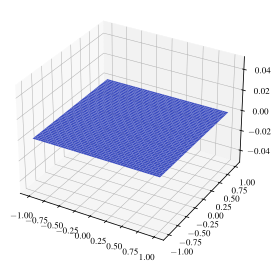

In [13]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

ax.plot_surface(plt_grid[..., 0], plt_grid[..., 1], prior_gp.mean(plt_grid), cmap="coolwarm")

## Conditioning on Boundary Conditions

In [14]:
def _normalize_xy(X, Y, d=2):
    X = np.asarray(X)
    Y = np.asarray(Y)
    if X.ndim == 3 and X.shape[0] == 1 and X.shape[-1] == d:
        X = X[0]                  # (N, d)
    if Y.ndim == 2 and Y.shape[0] == 1 and Y.shape[1] == X.shape[0]:
        Y = Y[0]                  # (N,)
    X = X.reshape(-1, d)
    Y = Y.reshape(-1)
    return X, Y

N_bc = 20
u_bc = prior_gp
X_bc_list = []

for boundary_condition in bvp.boundary_conditions:
    X_bc = boundary_condition.boundary.uniform_grid(N_bc, inset=1e-6)
    Y_bc = boundary_condition.values(X_bc)
    X_bc, Y_bc = _normalize_xy(X_bc, Y_bc, d=2)
    X_bc_list.append(X_bc)

    assert X_bc.shape == (N_bc, 2)
    assert Y_bc.shape == (N_bc,)

    jitter = 1e-6
    noise = pn.randvars.Normal(
        mean=np.zeros(Y_bc.shape),
        cov=jitter * np.eye(Y_bc.shape[0])
    )

    u_bc = u_bc.condition_on_observations(Y_bc, X=X_bc, b=noise)

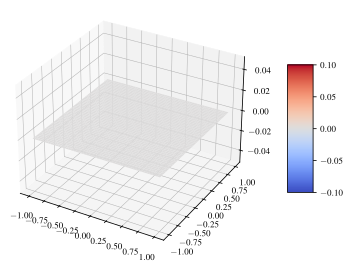

In [15]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

surf = ax.plot_surface(plt_grid[..., 0], plt_grid[..., 1], u_bc.mean(plt_grid), cmap="coolwarm")

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

### Conditioning on PDE Observations

In [16]:
N_pde = 10

X_pde = bvp.domain.uniform_grid((N_pde, N_pde), inset=1e-6)
Y_pde = bvp.pde.rhs(X_pde)

jitter = 1e-6
noise_pde = pn.randvars.Normal(
    mean=np.zeros(Y_pde.shape),
    cov=jitter * np.eye(Y_pde.size)
)
u_bc_pde = u_bc.condition_on_observations(
    Y=Y_pde,
    L=bvp.pde.diffop,
    X=X_pde,
    b=noise_pde
)

### Visualization

Figure 1: Problem Setup...


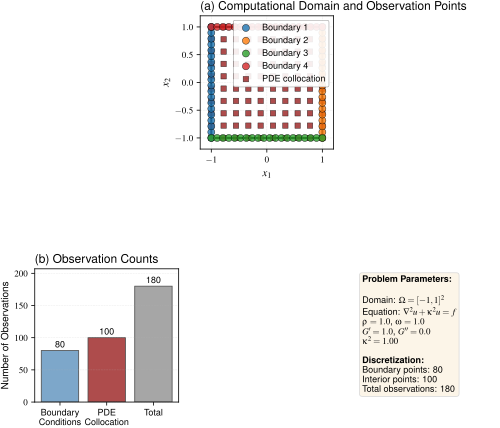

In [17]:
print("Figure 1: Problem Setup...")
fig1 = plot_problem_setup(bvp, X_bc_list, X_pde)
plt.show()

Figure 2: Posterior Solution (2D)...


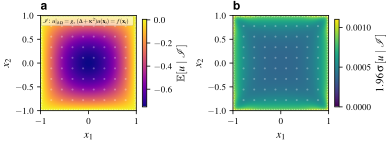

In [18]:
print("Figure 2: Posterior Solution (2D)...")
fig2 = plot_posterior_solution(plt_grid, u_bc_pde, X_pde=X_pde, X_bc_list=X_bc_list)
fig2.savefig('./helmholtz2d_posterior_100pts.pdf', bbox_inches='tight')
plt.show()

In [19]:
def plot_pde_satisfaction(
    plt_grid, u_post, bvp, X_pde=None,
    extent=(-1, 1, -1, 1), figsize=(8, 2.4),
    show_domain_outline=True,
):
    """Visualize how well the posterior satisfies the PDE.
    
    Shows: (a) E[(Δ + κ²)u | I], (b) true RHS f, (c) residual/error
    
    Parameters
    ----------
    plt_grid : np.ndarray
        Grid for visualization
    u_post : pn.randprocs.GaussianProcess
        Posterior GP
    bvp : linpde_gp.problems.pde.HelmholtzEquationDirichletProblem
        The BVP
    X_pde : np.ndarray, optional
        PDE collocation points
    extent : tuple
        Plot extent
    figsize : tuple
        Figure size (wider for 3 panels)
    show_domain_outline : bool
        Show domain boundary
    """
    
    grid_coords = np.asarray(plt_grid)
    Ny, Nx = grid_coords.shape[:2]
    
    # Apply operator
    helmholtz_u_post = bvp.pde.diffop(u_post)
    Lu_mean = np.asarray(helmholtz_u_post.mean(grid_coords))
    if Lu_mean.shape != (Ny, Nx):
        Lu_mean = Lu_mean.reshape(Ny, Nx)
    
    # True RHS
    f_true = np.asarray(bvp.pde.rhs(grid_coords))
    if f_true.shape != (Ny, Nx):
        f_true = f_true.reshape(Ny, Nx)
    
    # Residual
    residual = Lu_mean - f_true
    
    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)
    
    k_sq = bvp.pde.k_squared
    
    # (a) Operator-applied mean
    im1 = axes[0].imshow(
        Lu_mean, cmap='plasma', extent=extent, origin='lower',
        aspect='equal', interpolation='bilinear'
    )
    axes[0].set_xlabel(r'$x_1$')
    axes[0].set_ylabel(r'$x_2$')
    axes[0].set_title(r'\textbf{a}', loc='left', fontweight='bold')
    cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    cbar1.set_label(rf'$\mathbb{{E}}[(\Delta + {k_sq:.2f}) u \mid \mathcal{{I}}]$')
    
    # (b) True RHS
    im2 = axes[1].imshow(
        f_true, cmap='plasma', extent=extent, origin='lower',
        aspect='equal', interpolation='bilinear'
    )
    axes[1].set_xlabel(r'$x_1$')
    axes[1].set_ylabel(r'$x_2$')
    axes[1].set_title(r'\textbf{b}', loc='left', fontweight='bold')
    cbar2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    cbar2.set_label(r'$f(\mathbf{x})$')
    
    # (c) Residual (diverging colormap centered at 0)
    vmax_res = np.max(np.abs(residual))
    im3 = axes[2].imshow(
        residual, cmap='RdBu_r', extent=extent, origin='lower',
        aspect='equal', interpolation='bilinear',
        vmin=-vmax_res, vmax=vmax_res
    )
    axes[2].set_xlabel(r'$x_1$')
    axes[2].set_ylabel(r'$x_2$')
    axes[2].set_title(r'\textbf{c}', loc='left', fontweight='bold')
    cbar3 = fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    cbar3.set_label(rf'$\mathbb{{E}}[(\Delta + {k_sq:.2f}) u \mid \mathcal{{I}}] - f$')
    
    for ax in axes:
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        if show_domain_outline:
            ax.add_patch(
                patches.Rectangle(
                    (extent[0], extent[2]),
                    extent[1] - extent[0],
                    extent[3] - extent[2],
                    linewidth=1.0,
                    edgecolor='white',
                    facecolor='none',
                    alpha=0.7,
                )
            )
    
    # Overlay PDE points
    if X_pde is not None:
        X_pde_flat = np.asarray(X_pde).reshape(-1, 2)
        for ax in axes:
            ax.scatter(X_pde_flat[:, 0], X_pde_flat[:, 1],
                      s=6, c='white', alpha=0.4, linewidth=0, marker='o')
    
    return fig

Figure 3: PDE Satisfaction Analysis...


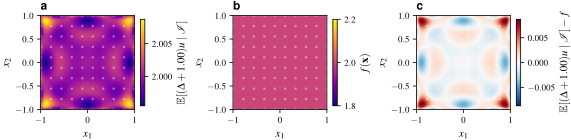

In [20]:
print("Figure 3: PDE Satisfaction Analysis...")
fig3 = plot_pde_satisfaction(plt_grid, u_bc_pde, bvp, X_pde=X_pde)
fig3.savefig('./helmholtz2d_pde_residual_100pts.pdf', bbox_inches='tight')
plt.show()

In [21]:
def analytical_constant_source(X, Y, k_squared=1.0, M=101, N=101):
    xi = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    dtype = complex if np.iscomplexobj(k_squared) else float
    u = np.zeros_like(X, dtype=dtype)

    for m in range(1, M, 2):
        for n in range(1, N, 2):
            lam = (np.pi * m / 2) ** 2 + (np.pi * n / 2) ** 2
            denom = -lam + k_squared
            coeff = 32.0 / (np.pi ** 2 * m * n * denom)
            u += coeff * np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta)

    return u

nx, ny = 31, 31
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y, indexing="ij")
pts = np.hstack([X.reshape(-1, 1), Y.reshape(-1, 1)])

u_pigp = u_bc_pde.mean(pts).reshape(nx, ny)

# Analytical solution
k_squared = bvp.pde.k_squared
u_true = analytical_constant_source(X, Y, k_squared=k_squared, M=101, N=101)
u_true_real = np.real(u_true)

# Compute metrics
rel_l2 = np.linalg.norm(u_pigp - u_true_real) / np.linalg.norm(u_true_real)
max_err = np.max(np.abs(u_pigp - u_true_real))
rmse = np.sqrt(np.mean((u_pigp - u_true_real) ** 2))
mae = np.mean(np.abs(u_pigp - u_true_real))
mse = np.mean((u_pigp - u_true_real) ** 2)

print("=" * 70)
print("LinPDE-GP Evaluation")
print("=" * 70)
print(f"\nGrid: {nx}×{ny}")
print(f"k² = {k_squared}")
print("\nEvaluation Metrics:")
print("-" * 40)
print(f"  {'MSE':15s}: {mse:.6e}")
print(f"  {'RELATIVE_L2':15s}: {rel_l2:.6e}")
print(f"  {'MAX_ERROR':15s}: {max_err:.6e}")
print(f"  {'RMSE':15s}: {rmse:.6e}")
print(f"  {'MAE':15s}: {mae:.6e}")
print(f"\n  Solution range: [{np.min(u_pigp):.4f}, {np.max(u_pigp):.4f}]")

LinPDE-GP Evaluation

Grid: 31×31
k² = 1.0

Evaluation Metrics:
----------------------------------------
  MSE            : 6.528965e-07
  RELATIVE_L2    : 2.019901e-03
  MAX_ERROR      : 4.574853e-03
  RMSE           : 8.080201e-04
  MAE            : 4.164245e-04

  Solution range: [-0.7530, 0.0046]
